## Ансамбли алгоритмов

Мы только что увидели, насколько сильно может измениться дерево решений даже при минимальных изменениях в обучающих данных:
- удаление всего 10% объектов
- добавление небольшого шума

Меняется:
- структура дерева (глубина, первые разбиения, количество листьев и узлов)
- качество на тестовой выборке

Это происходит потому, что алгоритм построения дерева **жадный** и **детерминированный**

В результате одиночное дерево:
- очень чувствительно к шуму и выбросам
- склонно к переобучению (запоминает обучающие данные, включая шум)
- даёт нестабильные предсказания при небольших изменениях выборки

### Как бороться с этой неустойчивостью?

**Ансамбли** — это подход, когда мы обучаем **много** слабых моделей и комбинируем их предсказания.  
Идея простая: если каждая модель ошибается по-своему, то их усреднение (или голосование) даёт гораздо более стабильный и точный результат.

### Основные виды ансамблей

1. **Bagging (Bootstrap Aggregating)**  
   - Обучаем много моделей на **разных** подвыборках данных  
   - Каждая подвыборка — бутстреп (выборка с возвращением того же размера)  
   - Для регрессии: усредняем предсказания всех моделей  
   - Для классификации: голосуем большинством  
   → сильно снижает **дисперсию** (разброс), почти не увеличивая смещение

2. **Random Forest** — это улучшенный Bagging  
   - К бутстрепу добавляется ещё один слой случайности:  
     при каждом разбиении узла берётся **случайное подмножество признаков**
   - Деревья становятся менее похожими друг на друга → их ошибки лучше компенсируют друг друга  
   Преимущества Random Forest:  
   - почти не переобучается  
   - очень высокое качество «из коробки»  
   - встроенная оценка важности признаков  

3. **Бустинг** (XGBoost, CatBoost, LightGBM)  
   - Модели обучаются **последовательно**  
   - Каждая следующая модель исправляет ошибки предыдущих  
   → снижает и смещение, и дисперсию
   - Являются передовыми в решении табличных задач

### Почему ансамбли работают лучше одиночного дерева?

- **Разнообразие моделей** → ошибки разных деревьев компенсируют друг друга  
- **Усреднение / голосование** → снижает влияние шума и выбросов  
- **Снижение дисперсии** без сильного роста смещения  


## Фишки RandomForest

### OOB-score (Out-of-Bag score)

**OOB-score** — это внутренняя оценка качества модели Random Forest, которую можно получить **бесплатно**, без отдельной валидационной выборки.

**Как считается:**

- Каждое дерево обучается на своей бутстреп-выборке (примерно 63% объектов из train, остальные ~37% не попадают в неё — это и есть out-of-bag объекты)
- Для каждого объекта из train считается предсказание **только теми деревьями**, которые его **не** видели при обучении
- Затем все такие предсказания усредняются (или голосуются) - получаем предсказание для объекта

**Преимущества:**
- Не требует отдельного hold-out или кросс-валидации
- Обычно очень близок к качеству на тестовой выборке (особенно при большом числе деревьев)
- Стабилен и почти не зависит от random_state

### feature_importances_ (встроенная важность)

**Что это:** встроенная оценка важности признаков в деревьях и лесах.

**Как считается:** сумма уменьшения критерия (Gini/MSE) по всем разбиениям, где признак использовался (усреднённая по деревьям).

**Плюсы:** мгновенно доступна, легко визуализировать.

**Минусы:**  
- завышает важность коррелированных/«дешёвых» признаков  
- считается только на train - не отражает реальное влияние на новых данных

## Задача 4

Random Forest решает проблему неусточивойсти решения за счёт обучения **множества деревьев** на разных подвыборках данных (бутстреп) и случайного выбора признаков при каждом разбиении. В результате усреднение предсказаний многих деревьев даёт гораздо более стабильный и точный результат.

1. **Обучение базового Random Forest без подбора гиперпараметров**  
   - Обучи модель `RandomForestRegressor` из `sklearn.ensemble` на тех же `X_train`, `y_train`  
   - Включи `oob_score=True` (out-of-bag оценка качества)  
   - Посчитай метрики на тестовой выборке: MSE, MAE, R²  
   - Выведи также oob_score_  
   - Запиши результаты

2. **Подбор гиперпараметров для Random Forest**  
   - Задай сетку гиперпараметров (не слишком большую, чтобы поиск не занял много времени):   
   - Используй `GridSearchCV` (или `RandomizedSearchCV`) с cv=3–5 и метрикой `neg_mean_squared_error`  
   - Обучи поиск  
   - Выведи лучшие параметры и качество на тестовой выборке для модели с найденными параметрами  
   - Сравни с базовым Random Forest (без подбора)

3. **OOB-score и его интерпретация**  
   - Для лучшей модели из пункта 2 (или базовой) включи `oob_score=True`  
   - Сравни значение `oob_score_` с качеством на тестовой выборке (RMSE / MAE / R²)  
   - Повтори обучение 2–3 раза с разными `random_state` и сравни стабильность OOB-score и test-метрик  

4. **Сравнение важности признаков**  
   - Построй график важности признаков для лучшего Random Forest (`feature_importances_`, топ-10 признаков)  
   - Посчитай **Permutation Importance** на тестовой выборке (используй `sklearn.inspection.permutation_importance`)  
   - Сравни два списка топ-10 признаков: встроенная важность RF и permutation importance  
   - Построй два графика barplot рядом для наглядности  

5. **Cравнение с лучшей моделью с одним деревом**  
   - Сравни важность признаков с той, что была у лучшего одиночного дерева из Задачи 2  
   - Сделай выводы о преимуществах Random Forest над одиночным деревом в этой задаче

In [56]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [57]:
rf_base = RandomForestRegressor(
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)
mse_base_rf = mean_squared_error(y_test, y_pred_base)
mae_base_rf = mean_absolute_error(y_test, y_pred_base)
r2_base_rf  = r2_score(y_test, y_pred_base)

print(f"Test → MSE: {mse_base_rf:.4f} | MAE: {mae_base_rf:.4f} | R²: {r2_base_rf:.4f}")
print(f"OOB score: {rf_base.oob_score_:.4f}")

Test → MSE: 0.0183 | MAE: 0.0927 | R²: 0.6173
OOB score: 0.6571


In [66]:
param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [15, 20],
    'max_features': ['sqrt', 0.3],
    'min_samples_leaf': [1, 3, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True),
    param_grid_rf,
    cv=4,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

rf_best = grid_rf.best_estimator_

print("\nЛучшие параметры:", grid_rf.best_params_)

y_pred_best_rf = rf_best.predict(X_test)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
r2_best_rf  = r2_score(y_test, y_pred_best_rf)
print(f"Лучший RF → Test: MSE={mse_best_rf:.4f} | MAE={mae_best_rf:.4f} | R²={r2_best_rf:.4f}")

Fitting 4 folds for each of 24 candidates, totalling 96 fits

Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 300}
Лучший RF → Test: MSE=0.0178 | MAE=0.0916 | R²=0.6276


In [60]:
oob_scores = []
for rs in range(1, 100, 10):
    rf_temp = RandomForestRegressor(
        **grid_rf.best_params_,
        oob_score=True,
        random_state=rs,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    oob_scores.append(rf_temp.oob_score_)

print("OOB-score при разных random_state:", [f"{x:.4f}" for x in oob_scores])
print(f"Средний OOB-score: {np.mean(oob_scores):.4f}")
print(f"Сравнение с test R² лучшего RF: {r2_best_rf:.4f}")

OOB-score при разных random_state: ['0.6727', '0.6698', '0.6691', '0.6666', '0.6703', '0.6693', '0.6720', '0.6708', '0.6700', '0.6708']
Средний OOB-score: 0.6701
Сравнение с test R² лучшего RF: 0.6276


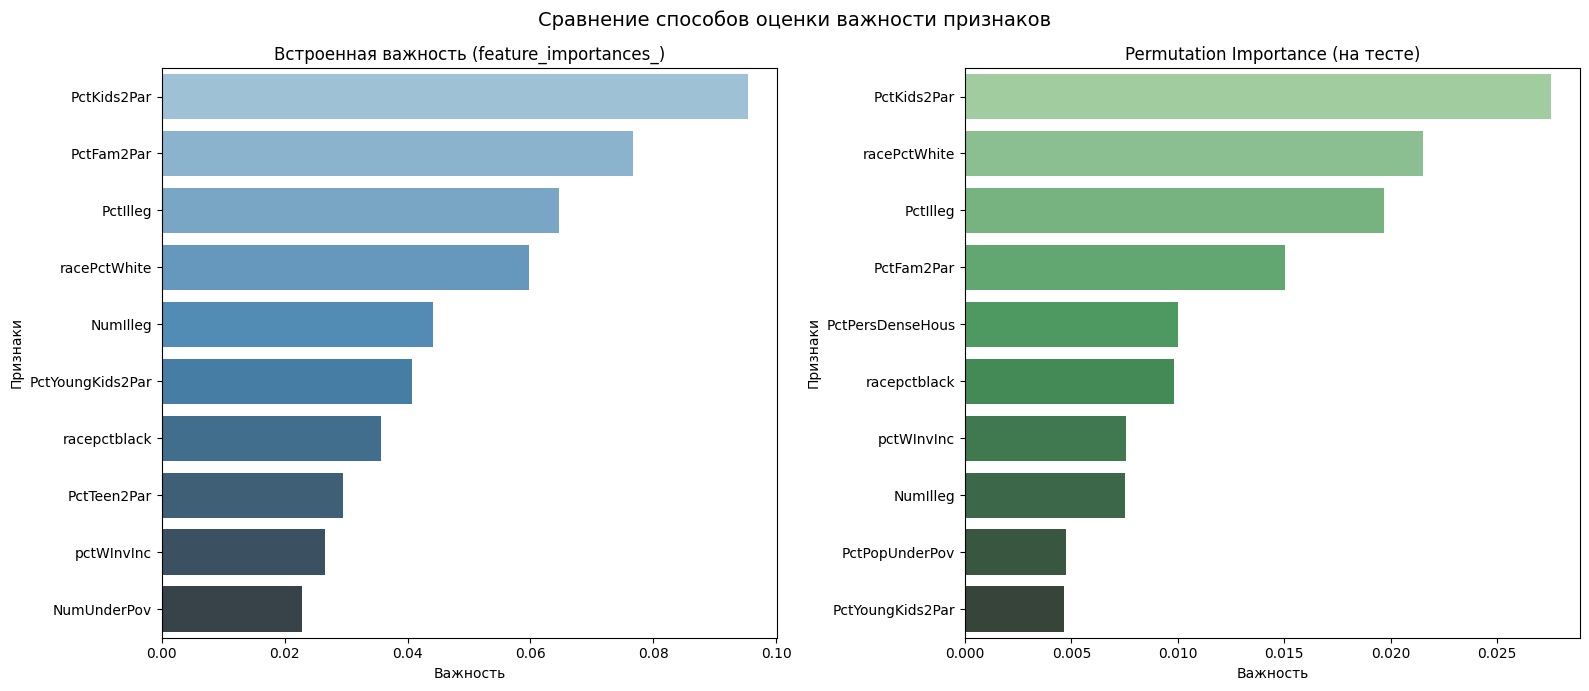

Топ-5 по встроенной важности: ['PctKids2Par', 'PctFam2Par', 'PctIlleg', 'racePctWhite', 'NumIlleg']
Топ-5 по Permutation Importance: ['PctKids2Par', 'racePctWhite', 'PctIlleg', 'PctFam2Par', 'PctPersDenseHous']


In [63]:
importances_rf = pd.Series(rf_best.feature_importances_, index=X.columns)\
                    .sort_values(ascending=False)[:10]

perm_importance = permutation_importance(rf_best, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_sorted_idx = perm_importance.importances_mean.argsort()[-10:]
perm_importances = pd.Series(perm_importance.importances_mean[perm_sorted_idx], 
                             index=X.columns[perm_sorted_idx])\
                    .sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x=importances_rf.values, y=importances_rf.index, ax=axes[0], palette='Blues_d')
axes[0].set_title("Встроенная важность (feature_importances_)")
axes[0].set_ylabel("Признаки")
axes[0].set_xlabel("Важность")

sns.barplot(x=perm_importances.values, y=perm_importances.index, ax=axes[1], palette='Greens_d')
axes[1].set_title("Permutation Importance (на тесте)")
axes[1].set_ylabel("Признаки")
axes[1].set_xlabel("Важность")

plt.suptitle("Сравнение способов оценки важности признаков", fontsize=14)
plt.tight_layout()
plt.show()

print("Топ-5 по встроенной важности:", list(importances_rf.index[:5]))
print("Топ-5 по Permutation Importance:", list(perm_importances.index[:5]))

In [67]:
comparison = pd.DataFrame({
    'Модель': [
        'Лучшее одиночное дерево',
        'Базовый Random Forest',
        'Лучший Random Forest'
    ],
    'MSE_test': [mse_best, mse_base_rf, mse_best_rf],
    'MAE_test': [mae_best, mae_base_rf, mae_best_rf],
    'R²_test':  [r2_best,  r2_base_rf,  r2_best_rf],
    'OOB_score': [np.nan, rf_base.oob_score_, rf_best.oob_score_]
}).round(4)

print("\n=== Сводная таблица сравнения ===")
print(comparison.sort_values('MSE_test'))


=== Сводная таблица сравнения ===
                    Модель  MSE_test  MAE_test  R²_test  OOB_score
2     Лучший Random Forest    0.0178    0.0916   0.6276     0.6696
1    Базовый Random Forest    0.0183    0.0927   0.6173     0.6571
0  Лучшее одиночное дерево    0.0218    0.0990   0.5456        NaN


## Задача 5

В этой задаче решите задачу **прогнозирования ежедневных продаж** магазинов Rossmann с помощью **CatBoost**.

1. **Загрузи и объедини данные**  
   - Загрузи `train.csv` и `store.csv`  
   - Объедини их по полю `Store`

2. **Подготовь признаки**  
   - Преобразуй `Date` в datetime  
   - Добавь временные признаки (год, месяц, день, день недели, неделя года и т.д.)  
   - Обработай пропуски  
   - Отфильтруй строки с `Open == 0`  
   - Примени `log1p` к `Sales` → `Sales_log`

3. **Раздели данные по времени**  
   - Отсортируй по дате  
   - Последние 6 недель — тестовая выборка  
   - Остальное — обучающая

4. **Обучи CatBoostRegressor**  
   - Укажи категориальные признаки через `cat_features`  
   - Подбери разумные параметры (iterations, learning_rate, depth и др.)  
   - Используй `eval_set` и early stopping  
   - Посчитай RMSE и MAE на expm1(pred) и expm1(true)

5. **Визуализация и выводы**  
   - Построй топ-15 важных признаков  
   - Построй `scatter plot` с истинными предсказаниями и предсказаниями модели

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.4168521	test: 0.4012566	best: 0.4012566 (0)	total: 322ms	remaining: 5m 22s
100:	learn: 0.1889149	test: 0.1723263	best: 0.1723263 (100)	total: 20.6s	remaining: 3m 3s
200:	learn: 0.1735040	test: 0.1596285	best: 0.1596166 (199)	total: 43.9s	remaining: 2m 54s
300:	learn: 0.1651251	test: 0.1519880	best: 0.1519880 (300)	total: 1m 7s	remaining: 2m 37s
400:	learn: 0.1595275	test: 0.1468732	best: 0.1468732 (400)	total: 1m 34s	remaining: 2m 21s
500:	learn: 0.1558591	test: 0.1434170	best: 0.1434170 (500)	total: 2m 3s	remaining: 2m 3s
600:	learn: 0.1526447	test: 0.1407712	best: 0.1407712 (600)	total: 2m 29s	remaining: 1m 39s
700:	learn: 0.1496323	test: 0.1381385	best: 0.1381385 (700)	total: 3m 2s	remaining: 1m 17s
800:	learn: 0.1471475	test: 0.1362517	best: 0.1362517 (800)	total: 3m 32s	remaining: 52.9s
900:	learn: 0.1452689	test: 0.1342458	best: 0.1342458 (900)	total: 3m 58s	remaining: 26.2s
999:	learn: 0.1437117	test: 0.1328048	best: 0.1328048 (999)	total: 4m 23s	remaining: 0us

best

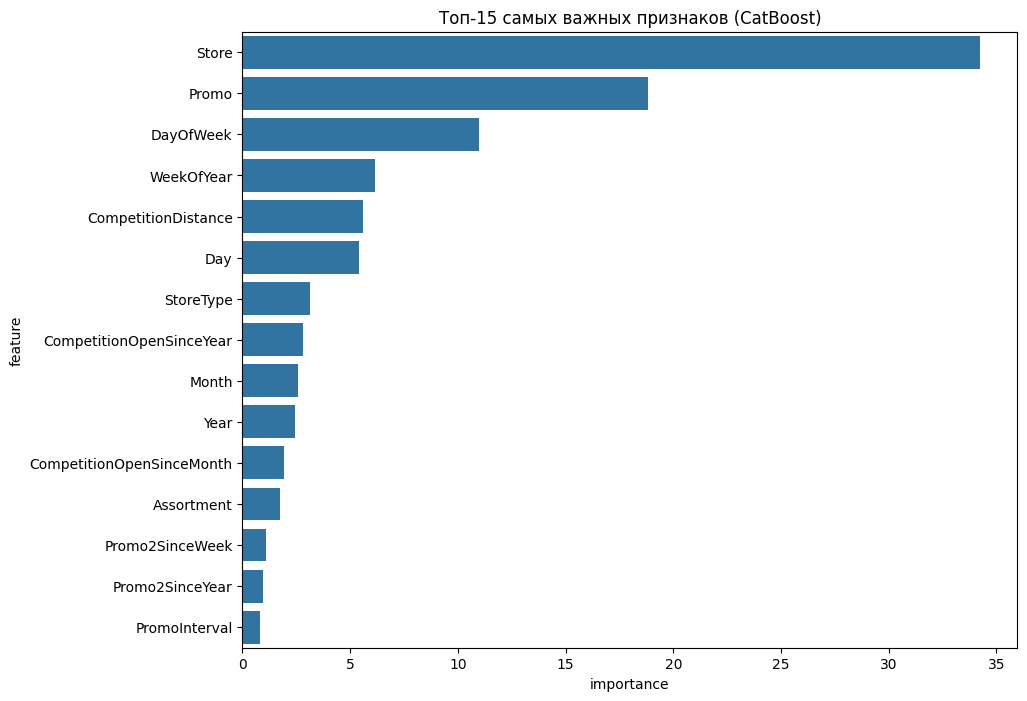

In [28]:
train = pd.read_csv('../../production/AI_Machine_Learning.Project_4.ID_1577774/datasets/train.csv', parse_dates=['Date'])
store = pd.read_csv('../../production/AI_Machine_Learning.Project_4.ID_1577774/datasets/store.csv')

df = train.merge(store, on='Store', how='left')

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Date'].dt.dayofweek + 1

categorical_features = [
    'Store', 'DayOfWeek', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'PromoInterval'
]

df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)
df['CompetitionOpenSinceMonth'].fillna(1, inplace=True)
df['CompetitionOpenSinceYear'].fillna(df['Year'].median(), inplace=True)
df['Promo2SinceWeek'].fillna(0, inplace=True)
df['Promo2SinceYear'].fillna(0, inplace=True)
df['PromoInterval'].fillna('None', inplace=True)

df['Sales_log'] = np.log1p(df['Sales']) 

df = df[df['Open'] == 1].copy()

df.sort_values('Date', inplace=True)
cutoff_date = df['Date'].max() - pd.Timedelta(weeks=6)
train_df = df[df['Date'] <= cutoff_date]
test_df  = df[df['Date'] > cutoff_date]

features = [
    'Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance',
    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
    'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval',
    'Year', 'Month', 'Day', 'WeekOfYear'
]

X_train = train_df[features]
y_train = train_df['Sales_log']

X_test = test_df[features]
y_test = test_df['Sales_log']

# Категориальные признаки (CatBoost сам их обработает)
cat_features_idx = [features.index(col) for col in categorical_features if col in features]

# 4. Обучение CatBoost
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    random_seed=42,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=100,
    cat_features=cat_features_idx,
    early_stopping_rounds=100
)

for col in categorical_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna('missing').astype(str)
        X_test[col]  = X_test[col].fillna('missing').astype(str)

train_pool = Pool(X_train, y_train, cat_features=cat_features_idx)
test_pool  = Pool(X_test, y_test, cat_features=cat_features_idx)

model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True,
    plot=True
)

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log) 
y_true = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Топ-15 самых важных признаков (CatBoost)')
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


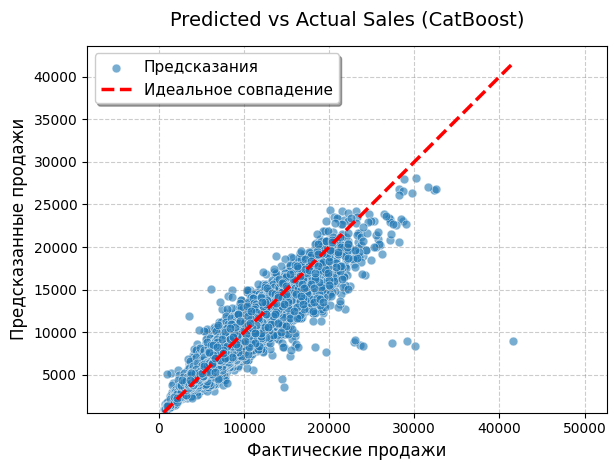

In [29]:
plt.scatter(y_true, y_pred, 
            alpha=0.6, 
            s=40,
            color='#1f77b4', 
            edgecolor='white', 
            linewidth=0.5,
            label='Предсказания')

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         'r--', lw=2.5, 
         label='Идеальное совпадение')

plt.xlabel('Фактические продажи', fontsize=12)
plt.ylabel('Предсказанные продажи', fontsize=12)
plt.title('Predicted vs Actual Sales (CatBoost)', fontsize=14, pad=15)

plt.grid(True, linestyle='--', alpha=0.4, color='gray')
plt.legend(fontsize=11, loc='upper left', frameon=True, shadow=True)

plt.axis('equal')

plt.xlim(min_val * 0.95, max_val * 1.05)
plt.ylim(min_val * 0.95, max_val * 1.05)

plt.tight_layout()
plt.show()